<table width="100%">
<tr>
<td width="50%" align="left"><a href="./04_RQ4_healthcare_access.ipynb">← Previous: RQ4 — Healthcare Access</a></td>
<td width="50%" align="right"><a href="./06_RQ6_system_performance.ipynb">Next: RQ6 — System Performance →</a></td>
</tr>
</table>

## **5.0 Healthcare Outcomes**

#### This section analysis how healthcare outcomes vary across Canadian provinces and how the differences are associated with healthcare resources, capacity, and access.

> - #### **Research Qeustion: How do healthcare outcomes vary across Canadian provinces and provinces, and how are these differences associated with healthcare resources, capacity, and access?**

In [288]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from dotenv import load_dotenv

import os

import matplotlib.pyplot as plt

In [289]:
import pandas as pd
from daytascape_db_core.connection import get_db_engine

In [290]:
DATABASE = "health_system_performance"

engine = get_db_engine(DATABASE)

print("Connected database:", engine.url.database)

Connected database: health_system_performance


In [291]:
query = """
SELECT *
FROM master.analytics_province_year;
"""

df = pd.read_sql(query, engine)

print("Connected successfully to database!")

df.head(10)

Connected successfully to database!


,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,private_health_expenditure_constant_2010_per_capita,provincial_government_health_expenditure_current,provincial_government_health_expenditure_per_capita,provincial_government_health_expenditure_constant_2010,provincial_government_health_expenditure_constant_2010_per_capi,territorial_government_health_expenditure_current,territorial_government_health_expenditure_per_capita,territorial_government_health_expenditure_constant_2010,territorial_government_health_expenditure_constant_2010_per_cap,nurses_total
0,15,PE,Prince Edward Island,2024,179709.0,36849.0,8218.0,3886.0,20.504816,4.572948,...,1914.110532,1.228779e+09,6881.989110,8.254174e+08,4622.892113,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,663.549287,6.949125e+08,384.207843,3.428803e+09,1895.739423,NaN,NaN,NaN,NaN,NaN
2,7,BC,British Columbia,1975,2499564.0,236960.0,51071.0,23239.0,9.480053,2.043196,...,679.794364,9.281825e+08,371.337761,4.379023e+09,1751.914626,NaN,NaN,NaN,NaN,NaN
3,7,BC,British Columbia,2022,5358845.0,1054174.0,250939.0,124925.0,19.671664,4.682707,...,2273.051979,3.010337e+10,5618.936230,2.317900e+10,4326.469070,NaN,NaN,NaN,NaN,108708.0
4,9,NB,New Brunswick,2021,790802.0,178652.0,39837.0,19193.0,22.591243,5.037544,...,2191.698134,3.945472e+09,4989.203072,3.151362e+09,3985.020465,NaN,NaN,NaN,NaN,NaN
5,5,CA,Canada,1975,23143275.0,1957075.0,377982.0,160362.0,8.456344,1.633226,...,568.363206,8.709289e+09,376.320519,4.111742e+10,1776.646681,NaN,NaN,NaN,NaN,NaN
6,8,MB,Manitoba,1975,1024975.0,104215.0,22287.0,9920.0,10.167565,2.174394,...,494.535967,3.766992e+08,367.520427,1.852127e+09,1806.997401,NaN,NaN,NaN,NaN,NaN
7,14,ON,Ontario,1980,8746013.0,850356.0,165961.0,70416.0,9.722785,1.897562,...,776.538159,5.164564e+09,590.505011,1.629120e+10,1862.700006,NaN,NaN,NaN,NaN,NaN
8,16,QC,Quebec,2020,8551095.0,1673371.0,401828.0,204785.0,19.569084,4.699141,...,1755.558556,4.704125e+10,5501.196296,3.642464e+10,4259.646558,NaN,NaN,NaN,NaN,NaN
9,14,ON,Ontario,2016,13876500.0,2260652.0,593482.0,302656.0,16.291226,4.276885,...,2000.807682,5.655294e+10,4075.446981,5.104966e+10,3678.856840,NaN,NaN,NaN,NaN,NaN


### **5.1 Avoidable Hospitalization Variation Accross Canadian Provinces and Territories (2022).**


In [292]:
access_columns = [
    "province_code",
    "province_name",
    "data_year",
    "bladder_cancer_surgery_median",
    "breast_cancer_surgery_median",
    "cabg_median",
    "cataract_surgery_median",
    "colorectal_cancer_surgery_median",
    "ct_scan_median",
    "hip_fracture_repair_median",
    "hip_fracture_repair_emergency_inpatient_median",
    "hip_replacement_median",
    "knee_replacement_median",
    "lung_cancer_surgery_median",
    "mri_scan_median",
    "prostate_cancer_surgery_median",
    "radiation_therapy_median",
    "bladder_cancer_surgery_90th_percentile",
    "breast_cancer_surgery_90th_percentile",
    "cabg_90th_percentile",
    "cataract_surgery_90th_percentile",
    "colorectal_cancer_surgery_90th_percentile",
    "ct_scan_90th_percentile",
    "hip_fracture_repair_90th_percentile",
    "hip_fracture_repair_emergency_inpatient_90th_percentile",
    "hip_replacement_90th_percentile",
    "knee_replacement_90th_percentile",
    "lung_cancer_surgery_90th_percentile",
    "mri_scan_90th_percentile",
    "prostate_cancer_surgery_90th_percentile",
    "radiation_therapy_90th_percentile",
    "joint_replacement_cases",
    "joint_replacement_pct_within_benchmark",
    "hip_fracture_surgery_risk_adjusted_rate"
]

df_access = df[access_columns].copy()

In [293]:
df[
    [
        "province_code",
        "province_name",
        "data_year",
        "avoidable_hospitalizations_age_standardized_rate"
    ]
].dropna(
    subset=["avoidable_hospitalizations_age_standardized_rate"]
).sort_values(["province_name", "data_year"])

,province_code,province_name,data_year,avoidable_hospitalizations_age_standardized_rate
578,AB,Alberta,2013,423.0
586,AB,Alberta,2014,423.0
203,AB,Alberta,2015,414.0
724,AB,Alberta,2016,403.0
594,AB,Alberta,2017,391.0
...,...,...,...,...
45,YT,Yukon,2020,476.0
518,YT,Yukon,2021,424.0
597,YT,Yukon,2022,425.0
305,YT,Yukon,2023,475.0


In [294]:
df.loc[
    df["avoidable_hospitalizations_age_standardized_rate"].notna(),
    ["province_code", "province_name", "data_year"]
].groupby(
    ["province_code", "province_name"]
)["data_year"].agg(["min", "max", "count"]).reset_index()

,province_code,province_name,min,max,count
0,AB,Alberta,2013,2024,12
1,BC,British Columbia,2013,2024,12
2,MB,Manitoba,2013,2024,12
3,NB,New Brunswick,2013,2024,12
4,NL,Newfoundland and Labrador,2013,2024,12
5,NS,Nova Scotia,2013,2024,12
6,NT,Northwest Territories,2013,2024,12
7,NU,Nunavut,2017,2021,2
8,ON,Ontario,2013,2024,12
9,PE,Prince Edward Island,2013,2024,12


In [295]:
df_avoidable_hospitalizations = (
    df[
        (df["data_year"] == 2022) & 
        (~df["province_code"].isin(["CA", "NU", "NT", "YT"]))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "avoidable_hospitalizations_age_standardized_rate"
        ]
    ].dropna(subset=["avoidable_hospitalizations_age_standardized_rate"])
    .sort_values("avoidable_hospitalizations_age_standardized_rate", ascending=False)
    .reset_index(drop=True)
)

In [296]:
df_avoidable_hospitalizations

,province_code,province_name,data_year,avoidable_hospitalizations_age_standardized_rate
0,SK,Saskatchewan,2022,455.0
1,NL,Newfoundland and Labrador,2022,434.0
2,PE,Prince Edward Island,2022,386.0
3,NS,Nova Scotia,2022,347.0
4,NB,New Brunswick,2022,345.0
5,AB,Alberta,2022,320.0
6,ON,Ontario,2022,313.0
7,MB,Manitoba,2022,285.0
8,QC,Quebec,2022,283.0
9,BC,British Columbia,2022,281.0


In [297]:
df_avoidable_hospitalizations["avoidable_hospitalizations_age_standardized_rate"].agg(["min", "max", "median", "mean"])

min       281.0
max       455.0
median    332.5
mean      344.9
Name: avoidable_hospitalizations_age_standardized_rate, dtype: float64

> ##### **Insights:** 
> - ##### Avoidable hospitalization rates varied substantially across the 10 provinces in 2022, ranging from 281 per 100,000 in British Columbia to 455 per 100,000 in Saskatchewan. Saskatchewan and Newfoundland and Labrador recorded the highest rates, while Manitoba, Quebec, and British Columbia recorded the lowest. The 174-per-100,000 difference between the highest and lowest provincial rates indicates considerable variation in avoidable hospitalization outcomes across provinces.

### **5.2 Avoidable Hospital Readmission Rates Variation Across Provinces (2022).**

In [298]:
df[
    [
        "province_code",
        "province_name",
        "data_year",
        "hospital_readmission_risk_adjusted_rate"
    ]
].dropna(subset=["hospital_readmission_risk_adjusted_rate"]
).groupby("province_code")["data_year"].agg(["min", "max", "count"])

,min,max,count
province_code,,,
AB,2020,2024,5
BC,2020,2024,5
MB,2020,2024,5
NB,2020,2024,5
NL,2020,2024,5
NS,2020,2024,5
NT,2020,2024,5
NU,2021,2024,4
ON,2020,2024,5


In [299]:
df_readmission = (
    df[
        (df["data_year"] == 2022)
        ][
            [
            "province_code",
            "province_name",
            "data_year",
            "hospital_readmission_risk_adjusted_rate"
        ]
    ]
    .dropna(subset=["hospital_readmission_risk_adjusted_rate"])
    .sort_values("hospital_readmission_risk_adjusted_rate", ascending=False)
    .reset_index(drop=True)
)

df_readmission

,province_code,province_name,data_year,hospital_readmission_risk_adjusted_rate
0,NT,Northwest Territories,2022,11.0
1,NU,Nunavut,2022,10.9
2,YT,Yukon,2022,10.4
3,BC,British Columbia,2022,9.4
4,SK,Saskatchewan,2022,9.2
5,ON,Ontario,2022,9.1
6,NL,Newfoundland and Labrador,2022,8.6
7,PE,Prince Edward Island,2022,8.6
8,MB,Manitoba,2022,8.5
9,AB,Alberta,2022,8.5


In [300]:
df_readmission["hospital_readmission_risk_adjusted_rate"].agg(["min", "max", "median", "mean"])

min        7.800000
max       11.000000
median     8.600000
mean       9.107692
Name: hospital_readmission_risk_adjusted_rate, dtype: float64

> ##### **Insights:** 
> - ##### Risk-adjusted 30-day hospital readmission rates varied across Canadian provinces in 2022, ranging from 7.8% in New Brunswick to 9.4% in British Columbia. British Columbia, Saskatchewan, and Ontario recorded the highest rates, while New Brunswick recorded the lowest. Since lower readmission rates are desirable, the results indicate substantial provincial variation in this healthcare outcome. 

### **5.3 Hip Fracture Outcomes Variation Across Provinces (2022).**

In [301]:
df_hip_fracture = (
    df[
        (df["data_year"] == 2022) &
        (~df["province_code"].isin(["CA", "NU", "NT", "YT"]))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "hip_fracture_surgery_risk_adjusted_rate"
        ]
    ]
    .dropna(subset=["hip_fracture_surgery_risk_adjusted_rate"])
    .sort_values("hip_fracture_surgery_risk_adjusted_rate", ascending=False)
    .reset_index(drop=True)
)

df_hip_fracture

,province_code,province_name,data_year,hip_fracture_surgery_risk_adjusted_rate
0,PE,Prince Edward Island,2022,86.1
1,AB,Alberta,2022,83.8
2,MB,Manitoba,2022,82.2
3,NL,Newfoundland and Labrador,2022,81.2
4,NS,Nova Scotia,2022,79.5
5,NB,New Brunswick,2022,78.6
6,SK,Saskatchewan,2022,78.4
7,ON,Ontario,2022,77.7
8,BC,British Columbia,2022,72.3


In [302]:
df_hip_fracture[
    "hip_fracture_surgery_risk_adjusted_rate"
].agg(["min", "max", "median", "mean"])

min       72.300000
max       86.100000
median    79.500000
mean      79.977778
Name: hip_fracture_surgery_risk_adjusted_rate, dtype: float64

> ##### **Insights:** 
> - ##### The proportion of hip-fracture patients receiving surgery within 48 hours varied substantially across provinces in 2022, ranging from 72.3% in British Columbia to 86.1% in Prince Edward Island. PEI, Alberta, and Manitoba recorded the highest rates, while British Columbia, Ontario, and Saskatchewan were among the lowest. Since higher rates indicate better performance, the results demonstrate meaningful provincial variation in timely hip-fracture care.

### **5.4 Variation of other Utilization (outcome) Indicators**

In [303]:
df_other_outcomes = (
    df[
        (df["data_year"] == 2022) &
        (~df["province_code"].isin(["CA", "NU", "NT", "YT"]))
    ][[
        "province_code",
        "province_name",
        "data_year",
        "joint_replacement_pct_within_benchmark",
        "standardized_hospitalization_rate"
    ]]
    .dropna(
        subset=[
            "joint_replacement_pct_within_benchmark",
            "standardized_hospitalization_rate"
        ]
    )
    .reset_index(drop=True)
)

df_other_outcomes.sort_values("joint_replacement_pct_within_benchmark", ascending=False)

,province_code,province_name,data_year,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate
7,QC,Quebec,2022,90.0,67.608700
9,ON,Ontario,2022,90.0,66.660687
5,SK,Saskatchewan,2022,78.0,95.900224
8,NL,Newfoundland and Labrador,2022,73.0,74.060013
4,NS,Nova Scotia,2022,66.0,68.488579
0,BC,British Columbia,2022,65.0,69.075949
2,NB,New Brunswick,2022,47.0,72.313104
6,AB,Alberta,2022,45.0,74.441547
1,PE,Prince Edward Island,2022,42.0,76.467100
3,MB,Manitoba,2022,39.0,73.156494


> ##### **Insights:** 
> - ##### The results above show that across all 10 provinces, there was substantial variation in access to joint replacement within the benchmark, ranging from 39% in Manitoba to 90% in Ontario and Quebec. Standardized hospitalization rates also varied considerably, with Saskatchewan recording the highest rate (95.9) and Ontario the lowest (66.7). The differences indicate meaningful variation in healthcare access and utilization across provinces, although hospitalization rates should not be interpreted as inherently positive or negative without considering the underlying health conditions and utilization context.

#### **5.5 How Helathcare Outcome has changed overtime**

#### **5.5.1 Change in Avoidable Hospitalizations (2020-2024)**

In [304]:
df_avoidable_hospitalizations_trends = (
    df[
        (df["data_year"].between(2020, 2024)) &
        (~df["province_code"].isin(["CA", "NU", "NT", "YT"]))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "avoidable_hospitalizations_age_standardized_rate"
        ]
    ]
    .dropna(subset=["avoidable_hospitalizations_age_standardized_rate"])
    .sort_values(["province_code", "data_year"])
    .reset_index(drop=True)
)
df_avoidable_hospitalizations_trends.head()

,province_code,province_name,data_year,avoidable_hospitalizations_age_standardized_rate
0,AB,Alberta,2020,264.0
1,AB,Alberta,2021,279.0
2,AB,Alberta,2022,320.0
3,AB,Alberta,2023,317.0
4,AB,Alberta,2024,326.0


In [305]:
df_avoidable_hospitalizations_change = (
    df_avoidable_hospitalizations_trends[
        df_avoidable_hospitalizations_trends["data_year"].between(2020, 2024)
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rate=("avoidable_hospitalizations_age_standardized_rate", "first"),
        end_rate=("avoidable_hospitalizations_age_standardized_rate", "last")
    )
    .reset_index()
)
df_avoidable_hospitalizations_change

,province_code,province_name,start_year,end_year,start_rate,end_rate
0,AB,Alberta,2020,2024,264.0,326.0
1,BC,British Columbia,2020,2024,245.0,278.0
2,MB,Manitoba,2020,2024,262.0,279.0
3,NB,New Brunswick,2020,2024,309.0,367.0
4,NL,Newfoundland and Labrador,2020,2024,340.0,429.0
5,NS,Nova Scotia,2020,2024,286.0,364.0
6,ON,Ontario,2020,2024,248.0,339.0
7,PE,Prince Edward Island,2020,2024,283.0,363.0
8,QC,Quebec,2020,2023,230.0,291.0
9,SK,Saskatchewan,2020,2024,355.0,444.0


In [306]:
df_avoidable_hospitalizations_change["absolute_change"] = (
    df_avoidable_hospitalizations_change["end_rate"]
    - df_avoidable_hospitalizations_change["start_rate"]
)

In [307]:
df_avoidable_hospitalizations_change["avoidable_hosp_growth_pct"] = (
    (df_avoidable_hospitalizations_change["end_rate"]
    - df_avoidable_hospitalizations_change["start_rate"])
    / df_avoidable_hospitalizations_change["start_rate"]
) * 100

df_avoidable_hospitalizations_change.sort_values("avoidable_hosp_growth_pct", ascending=False)

,province_code,province_name,start_year,end_year,start_rate,end_rate,absolute_change,avoidable_hosp_growth_pct
6,ON,Ontario,2020,2024,248.0,339.0,91.0,36.693548
7,PE,Prince Edward Island,2020,2024,283.0,363.0,80.0,28.268551
5,NS,Nova Scotia,2020,2024,286.0,364.0,78.0,27.272727
8,QC,Quebec,2020,2023,230.0,291.0,61.0,26.521739
4,NL,Newfoundland and Labrador,2020,2024,340.0,429.0,89.0,26.176471
9,SK,Saskatchewan,2020,2024,355.0,444.0,89.0,25.070423
0,AB,Alberta,2020,2024,264.0,326.0,62.0,23.484848
3,NB,New Brunswick,2020,2024,309.0,367.0,58.0,18.770227
1,BC,British Columbia,2020,2024,245.0,278.0,33.0,13.469388
2,MB,Manitoba,2020,2024,262.0,279.0,17.0,6.488550


> ##### **Insights:** 
> - ##### Between 2020 and 2024, avoidable hospitalization rates increased across all nine provinces with complete data, with percentage increases ranging from 6.5% in Manitoba to 36.7% in Ontario. Ontario recorded the largest increase, while Manitoba experienced the smallest. Quebec also recorded an increase of 26.5% between 2020 and 2023, but its absence of 2024 data prevents direct comparison with the other provinces over the full 2020–2024 period. Overall, the results indicate a broad increase in avoidable hospitalization rates during the period, although the magnitude of change varied considerably across provinces.

#### **5.5.2 Change in Hospital Readmission (2020-2004)**

In [308]:
df_readmission_trends = (
    df[
       (df["data_year"].between(2020, 2024))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "hospital_readmission_risk_adjusted_rate"
        ]
    ]
    .dropna(subset=["hospital_readmission_risk_adjusted_rate"])
    .sort_values(["province_code", "data_year"])
    .reset_index(drop=True)
)
df_readmission_trends.head(10)

,province_code,province_name,data_year,hospital_readmission_risk_adjusted_rate
0,AB,Alberta,2020,9.1
1,AB,Alberta,2021,9.1
2,AB,Alberta,2022,8.5
3,AB,Alberta,2023,8.8
4,AB,Alberta,2024,9.0
5,BC,British Columbia,2020,10.1
6,BC,British Columbia,2021,9.9
7,BC,British Columbia,2022,9.4
8,BC,British Columbia,2023,9.8
9,BC,British Columbia,2024,9.9


In [309]:
df_readmission_change = (
    df_readmission_trends
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rate=("hospital_readmission_risk_adjusted_rate", "first"),
        end_rate=("hospital_readmission_risk_adjusted_rate", "last")
    )
    .reset_index()
)
df_readmission_change

,province_code,province_name,start_year,end_year,start_rate,end_rate
0,AB,Alberta,2020,2024,9.1,9.0
1,BC,British Columbia,2020,2024,10.1,9.9
2,MB,Manitoba,2020,2024,9.4,9.0
3,NB,New Brunswick,2020,2024,9.2,8.3
4,NL,Newfoundland and Labrador,2020,2024,9.2,9.0
5,NS,Nova Scotia,2020,2024,8.8,8.7
6,NT,Northwest Territories,2020,2024,11.0,11.7
7,NU,Nunavut,2021,2024,11.0,10.9
8,ON,Ontario,2020,2024,9.7,9.7
9,PE,Prince Edward Island,2020,2024,8.5,8.8


In [310]:
df_readmission_change["absolute_change"] = (
    df_readmission_change["end_rate"]
    - df_readmission_change["start_rate"]
)

In [311]:
df_readmission_change["readmission_growth_pct"] = (
    (df_readmission_change["end_rate"]
    - df_readmission_change["start_rate"])
    / df_readmission_change["start_rate"]
) * 100

df_readmission_change.sort_values("readmission_growth_pct", ascending=False).round(2)

,province_code,province_name,start_year,end_year,start_rate,end_rate,absolute_change,readmission_growth_pct
12,YT,Yukon,2020,2024,9.4,12.4,3.0,31.91
6,NT,Northwest Territories,2020,2024,11.0,11.7,0.7,6.36
9,PE,Prince Edward Island,2020,2024,8.5,8.8,0.3,3.53
8,ON,Ontario,2020,2024,9.7,9.7,0.0,0.00
7,NU,Nunavut,2021,2024,11.0,10.9,-0.1,-0.91
0,AB,Alberta,2020,2024,9.1,9.0,-0.1,-1.10
5,NS,Nova Scotia,2020,2024,8.8,8.7,-0.1,-1.14
1,BC,British Columbia,2020,2024,10.1,9.9,-0.2,-1.98
4,NL,Newfoundland and Labrador,2020,2024,9.2,9.0,-0.2,-2.17
10,QC,Quebec,2020,2023,8.7,8.5,-0.2,-2.30


> ##### **Insights:** 
> - ##### Hospital readmission rates were relatively stable between 2020 and 2024, with most provinces recording modest declines. New Brunswick experienced the largest reduction, from 9.2% to 8.3%, while PEI was the only province with a notable increase. Ontario's rate remained unchanged at 9.7%. Overall, the results indicate a generally stable-to-improving pattern in risk-adjusted hospital readmissions across most provinces, although the magnitude of change varied.

#### **5.5.3 Change in Hip-fracture Surgery (2020-2024)**

In [312]:
df_hip_fracture_surgery_trends = (
    df[
        (~df["province_code"].isin(["CA", "NT", "YT", "NU"])) &
        (df["data_year"].between(2020, 2024))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "hip_fracture_surgery_risk_adjusted_rate"
        ]
    ]
    .dropna(subset=["hip_fracture_surgery_risk_adjusted_rate"])
    .sort_values(["province_code", "data_year"])
    .reset_index(drop=True)
)
df_hip_fracture_surgery_trends.head(10)

,province_code,province_name,data_year,hip_fracture_surgery_risk_adjusted_rate
0,AB,Alberta,2020,90.8
1,AB,Alberta,2021,89.7
2,AB,Alberta,2022,83.8
3,AB,Alberta,2023,82.0
4,AB,Alberta,2024,84.3
5,BC,British Columbia,2020,80.8
6,BC,British Columbia,2021,78.2
7,BC,British Columbia,2022,72.3
8,BC,British Columbia,2023,70.9
9,BC,British Columbia,2024,72.9


In [313]:
df_hip_fracture_surgery_change = (
    df_hip_fracture_surgery_trends
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rate=("hip_fracture_surgery_risk_adjusted_rate", "first"),
        end_rate=("hip_fracture_surgery_risk_adjusted_rate", "last")
    )
    .reset_index()
)
df_hip_fracture_surgery_change

,province_code,province_name,start_year,end_year,start_rate,end_rate
0,AB,Alberta,2020,2024,90.8,84.3
1,BC,British Columbia,2020,2024,80.8,72.9
2,MB,Manitoba,2020,2024,89.4,84.1
3,NB,New Brunswick,2020,2024,88.4,80.1
4,NL,Newfoundland and Labrador,2020,2024,85.8,80.3
5,NS,Nova Scotia,2020,2024,84.6,80.2
6,ON,Ontario,2020,2024,83.6,81.5
7,PE,Prince Edward Island,2020,2024,88.9,79.2
8,SK,Saskatchewan,2020,2024,81.7,76.3


In [314]:
df_hip_fracture_surgery_change["absolute_change"] = (
    df_hip_fracture_surgery_change["end_rate"]
    - df_hip_fracture_surgery_change["start_rate"]
)

In [315]:
df_hip_fracture_surgery_change["hip_surgery_growth_pct"] = (
    (df_hip_fracture_surgery_change["end_rate"]
    - df_hip_fracture_surgery_change["start_rate"])
    / df_hip_fracture_surgery_change["start_rate"]
) * 100

df_hip_fracture_surgery_change.sort_values("hip_surgery_growth_pct", ascending=False).round(2)

,province_code,province_name,start_year,end_year,start_rate,end_rate,absolute_change,hip_surgery_growth_pct
6,ON,Ontario,2020,2024,83.6,81.5,-2.1,-2.51
5,NS,Nova Scotia,2020,2024,84.6,80.2,-4.4,-5.20
2,MB,Manitoba,2020,2024,89.4,84.1,-5.3,-5.93
4,NL,Newfoundland and Labrador,2020,2024,85.8,80.3,-5.5,-6.41
8,SK,Saskatchewan,2020,2024,81.7,76.3,-5.4,-6.61
0,AB,Alberta,2020,2024,90.8,84.3,-6.5,-7.16
3,NB,New Brunswick,2020,2024,88.4,80.1,-8.3,-9.39
1,BC,British Columbia,2020,2024,80.8,72.9,-7.9,-9.78
7,PE,Prince Edward Island,2020,2024,88.9,79.2,-9.7,-10.91


> ##### **Insights:** 
> - ##### Between 2020 and 2024, the proportion of hip-fracture patients receiving surgery within 48 hours declined across all nine provinces with available data. Ontario recorded the smallest decline, from 83.6% to 81.5%, while Prince Edward Island experienced the largest, from 88.9% to 79.2%. The widespread decline indicates a deterioration in timely hip-fracture surgery performance across the provinces during the period, although the magnitude varied substantially.

#### **5.5.4 Change in Joint Replacement Within Benchmark (2020-2024)**

In [316]:
df_joint_replacement_trends = (
    df[
        (~df["province_code"].isin(["CA", "NT", "YT", "NU"])) &
        (df["data_year"].between(2020, 2024))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "joint_replacement_pct_within_benchmark"
        ]
    ]
    .dropna(subset=["joint_replacement_pct_within_benchmark"])
    .sort_values(["province_code", "data_year"])
    .reset_index(drop=True)
)
df_joint_replacement_trends.head(10)

,province_code,province_name,data_year,joint_replacement_pct_within_benchmark
0,AB,Alberta,2020,58.0
1,AB,Alberta,2021,73.0
2,AB,Alberta,2022,45.0
3,AB,Alberta,2023,61.0
4,AB,Alberta,2024,72.0
5,BC,British Columbia,2020,72.0
6,BC,British Columbia,2021,80.0
7,BC,British Columbia,2022,65.0
8,BC,British Columbia,2023,66.0
9,BC,British Columbia,2024,71.0


In [317]:
df_joint_replacement_change = (
   df_joint_replacement_trends
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rate=("joint_replacement_pct_within_benchmark", "first"),
        end_rate=("joint_replacement_pct_within_benchmark", "last")
    )
    .reset_index()
)
df_joint_replacement_change

,province_code,province_name,start_year,end_year,start_rate,end_rate
0,AB,Alberta,2020,2024,58.0,72.0
1,BC,British Columbia,2020,2024,72.0,71.0
2,MB,Manitoba,2020,2024,48.0,59.0
3,NB,New Brunswick,2020,2024,42.0,68.0
4,NL,Newfoundland and Labrador,2020,2024,47.0,83.0
5,NS,Nova Scotia,2020,2024,53.0,90.0
6,ON,Ontario,2020,2024,78.0,95.0
7,PE,Prince Edward Island,2020,2024,42.0,44.0
8,QC,Quebec,2020,2024,82.0,99.0
9,SK,Saskatchewan,2020,2024,80.0,97.0


In [318]:
df_joint_replacement_change["absolute_change"] = (
    df_joint_replacement_change["end_rate"]
    - df_joint_replacement_change["start_rate"]
)

In [319]:
df_joint_replacement_change["joint_replacement_growth_pct"] = (
    (df_joint_replacement_change["end_rate"]
    - df_joint_replacement_change["start_rate"])
    / df_joint_replacement_change["start_rate"]
) * 100

df_joint_replacement_change.sort_values("joint_replacement_growth_pct", ascending=False).round(2)

,province_code,province_name,start_year,end_year,start_rate,end_rate,absolute_change,joint_replacement_growth_pct
4,NL,Newfoundland and Labrador,2020,2024,47.0,83.0,36.0,76.60
5,NS,Nova Scotia,2020,2024,53.0,90.0,37.0,69.81
3,NB,New Brunswick,2020,2024,42.0,68.0,26.0,61.90
0,AB,Alberta,2020,2024,58.0,72.0,14.0,24.14
2,MB,Manitoba,2020,2024,48.0,59.0,11.0,22.92
6,ON,Ontario,2020,2024,78.0,95.0,17.0,21.79
9,SK,Saskatchewan,2020,2024,80.0,97.0,17.0,21.25
8,QC,Quebec,2020,2024,82.0,99.0,17.0,20.73
7,PE,Prince Edward Island,2020,2024,42.0,44.0,2.0,4.76
1,BC,British Columbia,2020,2024,72.0,71.0,-1.0,-1.39


> ##### **Insights:** 
> - ##### Between 2020 and 2024, the proportion of planned joint replacements completed within the benchmark improved in nine of the ten provinces. Nova Scotia recorded the largest absolute improvement, increasing from 53% to 90% (+37 percentage points), while Newfoundland and Labrador recorded the largest percentage increase (+76.6%). British Columbia was the only province to experience a decline, from 72% to 71%. Overall, the results indicate a broad improvement in timely joint-replacement performance across the provinces, although the magnitude of improvement varied substantially.

#### **5.5.5 Change in Standardized Hospitalization Rate (2020-2023)**

In [320]:
df_standardized_hospitalization_trends = (
    df[
        (~df["province_code"].isin(["CA", "NT", "YT", "NU"])) &
        (df["data_year"].between(2020, 2024))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "standardized_hospitalization_rate"
        ]
    ]
    .dropna(subset=["standardized_hospitalization_rate"])
    .sort_values(["province_code", "data_year"])
    .reset_index(drop=True)
)
df_standardized_hospitalization_trends.head(15)

,province_code,province_name,data_year,standardized_hospitalization_rate
0,AB,Alberta,2020,72.229955
1,AB,Alberta,2021,75.271922
2,AB,Alberta,2022,74.441547
3,AB,Alberta,2023,73.833910
4,BC,British Columbia,2020,67.619696
5,BC,British Columbia,2021,69.944801
6,BC,British Columbia,2022,69.075949
7,BC,British Columbia,2023,68.052868
8,MB,Manitoba,2020,73.851406
9,MB,Manitoba,2021,74.488895


In [321]:
df_standardized_hospitalization_change = (
   df_standardized_hospitalization_trends
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rate=("standardized_hospitalization_rate", "first"),
        end_rate=("standardized_hospitalization_rate", "last")
    )
    .reset_index()
)
df_standardized_hospitalization_change

,province_code,province_name,start_year,end_year,start_rate,end_rate
0,AB,Alberta,2020,2023,72.229955,73.833910
1,BC,British Columbia,2020,2023,67.619696,68.052868
2,MB,Manitoba,2020,2023,73.851406,69.123530
3,NB,New Brunswick,2020,2023,76.159894,72.596704
4,NL,Newfoundland and Labrador,2020,2023,71.455924,72.719534
5,NS,Nova Scotia,2020,2023,67.226093,67.064328
6,ON,Ontario,2020,2023,62.523178,67.462179
7,PE,Prince Edward Island,2020,2023,77.583658,73.970053
8,QC,Quebec,2020,2023,64.069962,67.624528
9,SK,Saskatchewan,2020,2023,88.355637,95.338740


In [322]:
df_standardized_hospitalization_change["absolute_change"] = (
df_standardized_hospitalization_change["end_rate"]
- df_standardized_hospitalization_change["start_rate"]
)

In [323]:
df_standardized_hospitalization_change["stand_hosp_growth_pct"] = (
    (
df_standardized_hospitalization_change["end_rate"]
- df_standardized_hospitalization_change["start_rate"]
)
/ df_standardized_hospitalization_change["start_rate"]
)
df_standardized_hospitalization_change.sort_values("stand_hosp_growth_pct", ascending=False).round(2)

,province_code,province_name,start_year,end_year,start_rate,end_rate,absolute_change,stand_hosp_growth_pct
9,SK,Saskatchewan,2020,2023,88.36,95.34,6.98,0.08
6,ON,Ontario,2020,2023,62.52,67.46,4.94,0.08
8,QC,Quebec,2020,2023,64.07,67.62,3.55,0.06
0,AB,Alberta,2020,2023,72.23,73.83,1.60,0.02
4,NL,Newfoundland and Labrador,2020,2023,71.46,72.72,1.26,0.02
1,BC,British Columbia,2020,2023,67.62,68.05,0.43,0.01
5,NS,Nova Scotia,2020,2023,67.23,67.06,-0.16,-0.00
7,PE,Prince Edward Island,2020,2023,77.58,73.97,-3.61,-0.05
3,NB,New Brunswick,2020,2023,76.16,72.60,-3.56,-0.05
2,MB,Manitoba,2020,2023,73.85,69.12,-4.73,-0.06


> ##### **Insights:** 
> - ##### Between 2020 and 2023, standardized hospitalization rates increased in six provinces and declined in four. Saskatchewan and Ontario recorded the largest increases, while Manitoba experienced the largest decline. The results therefore show considerable variation in the direction and magnitude of hospitalization-rate changes across provinces. Because 2024 data were unavailable for this indicator, the comparison is limited to 2020–2023.

> ##### **Insights:** 
> - ##### Healthcare outcomes showed mixed trends across Canadian provinces over the 2020–2024 analysis period. Avoidable hospitalization rates increased across all provinces with complete data, while 30-day hospital readmission rates were generally stable or declined. The proportion of hip-fracture patients receiving surgery within 48 hours declined across all provinces with available data, whereas the proportion of planned joint replacements completed within the benchmark improved in nine of ten provinces. Standardized hospitalization rates showed a mixed pattern, increasing in six provinces and declining in four between 2020 and 2023. 
> - ##### The results demonstrate substantial variation in the direction and magnitude of outcome changes across provinces, with no single trend characterizing healthcare system performance across all indicators. 

### **5.6 How healthcare outcomes are associated with healthcare resources**

In [325]:
df_healthcare_expenditure_per_capital_trend = (
    df[
        (~df["province_code"].isin(["CA", "NT", "YT", "NU"])) &
        (df["data_year"].between(2020, 2024))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "total_health_expenditure_constant_2010_per_capita"
        ]
    ]
    .dropna(subset=["total_health_expenditure_constant_2010_per_capita"])
    .sort_values(["province_code", "data_year"])
    .reset_index(drop=True)
)
df_healthcare_expenditure_per_capital_trend.head(15)

,province_code,province_name,data_year,total_health_expenditure_constant_2010_per_capita
0,AB,Alberta,2020,7071.447758
1,AB,Alberta,2021,7423.422597
2,AB,Alberta,2022,7329.923567
3,AB,Alberta,2023,7362.566390
4,AB,Alberta,2024,7102.729338
5,BC,British Columbia,2020,6585.584583
6,BC,British Columbia,2021,7077.897387
7,BC,British Columbia,2022,6965.802673
8,BC,British Columbia,2023,7124.562495
9,BC,British Columbia,2024,7310.940212


In [326]:
df_healthcare_expenditure_per_capital_change = (
   df_healthcare_expenditure_per_capital_trend
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rate=("total_health_expenditure_constant_2010_per_capita", "first"),
        end_rate=("total_health_expenditure_constant_2010_per_capita", "last")
    )
    .reset_index()
)
df_healthcare_expenditure_per_capital_change

,province_code,province_name,start_year,end_year,start_rate,end_rate
0,AB,Alberta,2020,2024,7071.447758,7102.729338
1,BC,British Columbia,2020,2024,6585.584583,7310.940212
2,MB,Manitoba,2020,2024,6717.440258,7273.684360
3,NB,New Brunswick,2020,2024,6572.929267,6762.348235
4,NL,Newfoundland and Labrador,2020,2024,7591.630318,8148.401687
5,NS,Nova Scotia,2020,2024,7133.673985,8133.803823
6,ON,Ontario,2020,2024,6425.435691,6476.721264
7,PE,Prince Edward Island,2020,2024,6454.489420,6838.970716
8,QC,Quebec,2020,2024,6609.410361,6217.866410
9,SK,Saskatchewan,2020,2024,6988.486013,7081.560195


In [327]:
df_healthcare_expenditure_per_capital_change["absolute_change"] = (
df_healthcare_expenditure_per_capital_change["end_rate"]
- df_healthcare_expenditure_per_capital_change["start_rate"]
)

In [330]:
df_healthcare_expenditure_per_capital_change["healthcare_percapita_exp_growth_pct"] = (
    (
df_healthcare_expenditure_per_capital_change["end_rate"]
- df_healthcare_expenditure_per_capital_change["start_rate"]
)
/ df_healthcare_expenditure_per_capital_change["start_rate"]
)

df_healthcare_expenditure_per_capital_change.sort_values("healthcare_percapita_exp_growth_pct", ascending=False).round(2)

,province_code,province_name,start_year,end_year,start_rate,end_rate,absolute_change,healthcare_percapita_exp_growth_pct
5,NS,Nova Scotia,2020,2024,7133.67,8133.80,1000.13,0.14
1,BC,British Columbia,2020,2024,6585.58,7310.94,725.36,0.11
2,MB,Manitoba,2020,2024,6717.44,7273.68,556.24,0.08
4,NL,Newfoundland and Labrador,2020,2024,7591.63,8148.40,556.77,0.07
7,PE,Prince Edward Island,2020,2024,6454.49,6838.97,384.48,0.06
3,NB,New Brunswick,2020,2024,6572.93,6762.35,189.42,0.03
9,SK,Saskatchewan,2020,2024,6988.49,7081.56,93.07,0.01
6,ON,Ontario,2020,2024,6425.44,6476.72,51.29,0.01
0,AB,Alberta,2020,2024,7071.45,7102.73,31.28,0.00
8,QC,Quebec,2020,2024,6609.41,6217.87,-391.54,-0.06


> ##### **Insights:** 
> - ##### Real healthcare expenditure per capita increased across most provinces between 2020 and 2024, with the largest increases in Nova Scotia (+14%) and British Columbia (+11%). Quebec was the only province to experience a decline (−6%), while Alberta, Ontario, and Saskatchewan remained broadly stable.


In [332]:
df_outcome_resources = (
    df[
        (df["data_year"] == 2022)
        & (~df["province_code"].isin(["CA", "NT", "YT", "NU"]))
    ][[
        "province_code",
        "province_name",
        "data_year",
        "total_health_expenditure_constant_2010_per_capita",
        "avoidable_hospitalizations_age_standardized_rate",
        "hospital_readmission_risk_adjusted_rate",
        "hip_fracture_surgery_risk_adjusted_rate",
        "joint_replacement_pct_within_benchmark",
        "standardized_hospitalization_rate"
    ]]
    .reset_index(drop=True)
)

df_outcome_resources.sort_values("total_health_expenditure_constant_2010_per_capita", ascending=False)

,province_code,province_name,data_year,total_health_expenditure_constant_2010_per_capita,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate
8,NL,Newfoundland and Labrador,2022,8167.953550,434.0,8.6,81.2,73.0,74.060013
4,NS,Nova Scotia,2022,7611.734757,347.0,8.2,79.5,66.0,68.488579
6,AB,Alberta,2022,7329.923567,320.0,8.5,83.8,45.0,74.441547
5,SK,Saskatchewan,2022,7160.469199,455.0,9.2,78.4,78.0,95.900224
0,BC,British Columbia,2022,6965.802673,281.0,9.4,72.3,65.0,69.075949
3,MB,Manitoba,2022,6835.770473,285.0,8.5,82.2,39.0,73.156494
2,NB,New Brunswick,2022,6781.423381,345.0,7.8,78.6,47.0,72.313104
9,ON,Ontario,2022,6556.048428,313.0,9.1,77.7,90.0,66.660687
1,PE,Prince Edward Island,2022,6524.847359,386.0,8.6,86.1,42.0,76.467100
7,QC,Quebec,2022,6513.088385,283.0,8.2,NaN,90.0,67.608700


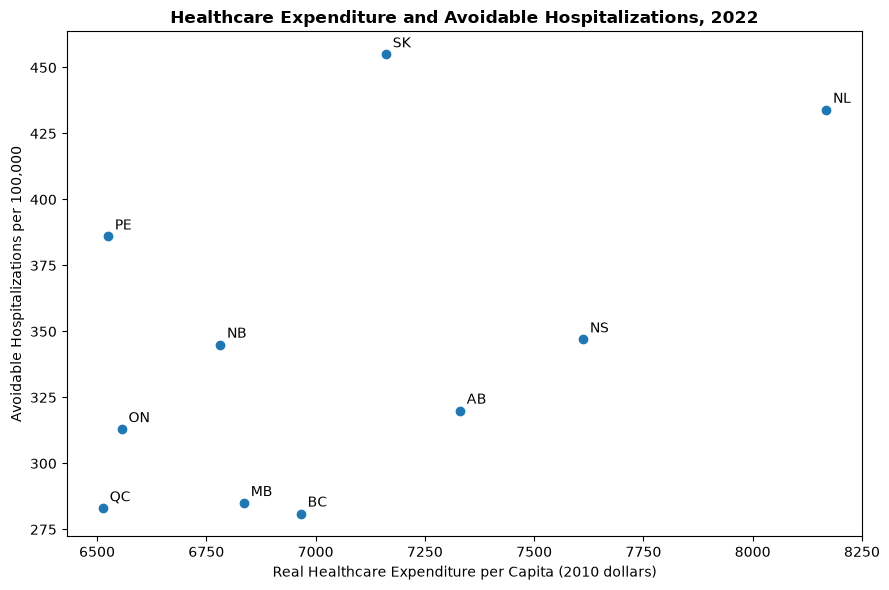

In [331]:
d = df_outcome_resources.query("data_year == 2022").dropna(
    subset=[
        "total_health_expenditure_constant_2010_per_capita",
        "avoidable_hospitalizations_age_standardized_rate"
    ]
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    d["total_health_expenditure_constant_2010_per_capita"],
    d["avoidable_hospitalizations_age_standardized_rate"]
)

for _, r in d.iterrows():
    ax.annotate(
        r["province_code"],
        (r["total_health_expenditure_constant_2010_per_capita"],
         r["avoidable_hospitalizations_age_standardized_rate"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_title(
    "Healthcare Expenditure and Avoidable Hospitalizations, 2022",
    fontweight="bold"
)
ax.set_xlabel("Real Healthcare Expenditure per Capita (2010 dollars)")
ax.set_ylabel("Avoidable Hospitalizations per 100,000")


plt.tight_layout()
plt.show()

#### **5.6.1 - Expenditure and Outcomes**

In [ ]:
df_outcome_resources[
    [
        "total_health_expenditure_constant_2010_per_capita",
        "avoidable_hospitalizations_age_standardized_rate",
        "hospital_readmission_risk_adjusted_rate",
        "hip_fracture_surgery_risk_adjusted_rate",
        "joint_replacement_pct_within_benchmark",
        "standardized_hospitalization_rate"
    ]
].corr()

,total_health_expenditure_constant_2010_per_capita,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate
total_health_expenditure_constant_2010_per_capita,1.000000,0.504311,-0.020465,0.026098,0.021079,0.155304
avoidable_hospitalizations_age_standardized_rate,0.504311,1.000000,0.112266,0.263664,0.083616,0.739424
hospital_readmission_risk_adjusted_rate,-0.020465,0.112266,1.000000,-0.467610,0.334164,0.310152
hip_fracture_surgery_risk_adjusted_rate,0.026098,0.263664,-0.467610,1.000000,-0.552391,0.144978
joint_replacement_pct_within_benchmark,0.021079,0.083616,0.334164,-0.552391,1.000000,-0.054112
standardized_hospitalization_rate,0.155304,0.739424,0.310152,0.144978,-0.054112,1.000000


In [ ]:
resource_outcome_correlations = (
    df_outcome_resources[
        [
            "total_health_expenditure_constant_2010_per_capita",
            "avoidable_hospitalizations_age_standardized_rate",
            "hospital_readmission_risk_adjusted_rate",
            "hip_fracture_surgery_risk_adjusted_rate",
            "joint_replacement_pct_within_benchmark",
            "standardized_hospitalization_rate"
        ]
    ]
    .corr()["total_health_expenditure_constant_2010_per_capita"]
    
)

resource_outcome_correlations

total_health_expenditure_constant_2010_per_capita    1.000000
avoidable_hospitalizations_age_standardized_rate     0.504311
hospital_readmission_risk_adjusted_rate             -0.020465
hip_fracture_surgery_risk_adjusted_rate              0.026098
joint_replacement_pct_within_benchmark               0.021079
standardized_hospitalization_rate                    0.155304
Name: total_health_expenditure_constant_2010_per_capita, dtype: float64

> ##### **Insights:** 
> - ##### The correlation results show that healthcare expenditure per capita showed limited linear association with most healthcare outcome indicators across Canadian provinces. The strongest relationship was observed for avoidable hospitalization rates, with a moderate positive correlation of 0.50, indicating that provinces with higher expenditure per capita also tended to have higher avoidable hospitalization rates. By contrast, hospital readmission rates, hip-fracture surgery within 48 hours, and joint replacement performance showed correlations close to zero, while standardized hospitalization had only a weak positive correlation. 
> - #### These results indicate that higher aggregate healthcare expenditure per capita did not consistently correspond to better outcome performance across provinces. 

In [ ]:
df_outcome_resources.sort_values("total_health_expenditure_constant_2010_per_capita", ascending=False)

,province_code,province_name,data_year,total_health_expenditure_constant_2010_per_capita,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate
8,NL,Newfoundland and Labrador,2022,8167.953550,434.0,8.6,81.2,73.0,74.060013
4,NS,Nova Scotia,2022,7611.734757,347.0,8.2,79.5,66.0,68.488579
6,AB,Alberta,2022,7329.923567,320.0,8.5,83.8,45.0,74.441547
5,SK,Saskatchewan,2022,7160.469199,455.0,9.2,78.4,78.0,95.900224
0,BC,British Columbia,2022,6965.802673,281.0,9.4,72.3,65.0,69.075949
3,MB,Manitoba,2022,6835.770473,285.0,8.5,82.2,39.0,73.156494
2,NB,New Brunswick,2022,6781.423381,345.0,7.8,78.6,47.0,72.313104
9,ON,Ontario,2022,6556.048428,313.0,9.1,77.7,90.0,66.660687
1,PE,Prince Edward Island,2022,6524.847359,386.0,8.6,86.1,42.0,76.467100
7,QC,Quebec,2022,6513.088385,283.0,8.2,NaN,90.0,67.608700


### **5.7 Healthcare Outcomes and Healthcare Capacity in 2022**

In [ ]:
#### Please refer to notebook

query = """
SELECT
    Province_id,
    province_code,
    province_name,
    data_year,
    population,
    population_65_plus,
    population_80_plus,
    population_85_plus,
    population_65_share_pct,
    population_80_share_pct,
    population_85_share_pct,
    hospital_beds_total,
    current_hospital_beds_total,
    physicians_total,
    registered_nurses,
    licensed_practical_nurses,
    nurse_practitioners,
    registered_psychiatric_nurses,
    icu_beds,
    long_term_care_beds,
    mental_health_addictions_beds,
    obstetrics_beds,
    other_acute_care_beds,
    pediatrics_beds,
    rated_capacity_beds,
    rehabilitation_beds
FROM master.analytics_province_year
WHERE province_code NOT IN ('CA', 'NT', 'YT', 'NU')
ORDER BY province_name, data_year;
"""

df_healthcare_capacity = pd.read_sql(query, engine)

#### Changes in Bed Capacity Across Provinces
df_bed_capacity_change = (df_healthcare_capacity[
  df_healthcare_capacity["hospital_beds_total"].notna()
].groupby(
    ["province_code", "province_name"]
).agg(
    start_year=("data_year", "min"),
    end_year=("data_year", "max"),
    start_beds=("hospital_beds_total", "first"),
    end_beds=("hospital_beds_total", "last")
).reset_index()
)

##### Absolute Change in Bed Capacity
df_bed_capacity_change["bed_change_absolute"] = (
    df_bed_capacity_change["end_beds"] - df_bed_capacity_change["start_beds"]
)


 #### Changes in Bed Capacity Across Provinces
df_bed_capacity_change["bed_change_pct"] = (
    df_bed_capacity_change["bed_change_absolute"]
    / df_bed_capacity_change["start_beds"]
) * 100

df_healthcare_capacity["beds_per_100k"] = (
    df_healthcare_capacity["hospital_beds_total"]
    / df_healthcare_capacity["population"]
) * 100000


df_healthcare_capacity[
    df_healthcare_capacity["beds_per_100k"].notna()
].sort_values(
    ["province_code", "data_year"]
).head()

df_healthcare_capacity["physicians_per_100k"] = (
    df_healthcare_capacity["physicians_total"]
    /df_healthcare_capacity["population"]
) * 100000

In [ ]:
df_healthcare_capacity

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,icu_beds,long_term_care_beds,mental_health_addictions_beds,obstetrics_beds,other_acute_care_beds,pediatrics_beds,rated_capacity_beds,rehabilitation_beds,beds_per_100k,physicians_per_100k
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,...,66.0,22.0,401.0,116.0,1334.0,78.0,2061.0,80.0,356.081256,218.119038
546,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,...,77.0,0.0,523.0,187.0,2390.0,69.0,144.0,73.0,293.774326,221.073027
547,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.192689
548,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,217.090269


In [ ]:
df_outcome_2022 = (
    df[
        (df["data_year"] == 2022) &
        (~df["province_code"].isin(["CA", "NT", "YT", "NU"]))
    ][
        [
            "province_code",
            "province_name",
            "data_year",
            "avoidable_hospitalizations_age_standardized_rate",
            "hospital_readmission_risk_adjusted_rate",
            "hip_fracture_surgery_risk_adjusted_rate",
            "joint_replacement_pct_within_benchmark",
            "standardized_hospitalization_rate"
        ]
    ].reset_index(drop=True)
)
df_outcome_2022

,province_code,province_name,data_year,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate
0,BC,British Columbia,2022,281.0,9.4,72.3,65.0,69.075949
1,PE,Prince Edward Island,2022,386.0,8.6,86.1,42.0,76.467100
2,NB,New Brunswick,2022,345.0,7.8,78.6,47.0,72.313104
3,MB,Manitoba,2022,285.0,8.5,82.2,39.0,73.156494
4,NS,Nova Scotia,2022,347.0,8.2,79.5,66.0,68.488579
5,SK,Saskatchewan,2022,455.0,9.2,78.4,78.0,95.900224
6,AB,Alberta,2022,320.0,8.5,83.8,45.0,74.441547
7,QC,Quebec,2022,283.0,8.2,NaN,90.0,67.608700
8,NL,Newfoundland and Labrador,2022,434.0,8.6,81.2,73.0,74.060013
9,ON,Ontario,2022,313.0,9.1,77.7,90.0,66.660687


In [ ]:
df_beds_physician_capacity_2022 = (
 df_healthcare_capacity[
        (df_healthcare_capacity["data_year"] == 2022)
       ][
        [
            "province_code",
            "province_name",
            "data_year",
            "beds_per_100k",
            "physicians_per_100k"
        ]
    ].reset_index(drop=True)
)
df_beds_physician_capacity_2022

,province_code,province_name,data_year,beds_per_100k,physicians_per_100k
0,AB,Alberta,2022,240.630341,245.483278
1,BC,British Columbia,2022,232.494129,267.837566
2,MB,Manitoba,2022,295.578770,214.432564
3,NB,New Brunswick,2022,315.502263,267.410421
4,NL,Newfoundland and Labrador,2022,411.100465,266.349432
5,NS,Nova Scotia,2022,316.493398,269.326995
6,ON,Ontario,2022,229.489155,233.045541
7,PE,Prince Edward Island,2022,287.679426,212.918660
8,QC,Quebec,2022,228.766836,262.573208
9,SK,Saskatchewan,2022,293.774326,221.073027


In [ ]:
df_capacity_outcomes_2022 = df_outcome_2022.merge(
    df_beds_physician_capacity_2022[
        [
            "province_code",
            "province_name",
            "beds_per_100k",
            "physicians_per_100k"
        ]
    ],
    on=["province_code", "province_name"],
    how="inner"
)
df_capacity_outcomes_2022.sort_values(
    ["beds_per_100k", "physicians_per_100k"],
    ascending=False)

,province_code,province_name,data_year,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate,beds_per_100k,physicians_per_100k
8,NL,Newfoundland and Labrador,2022,434.0,8.6,81.2,73.0,74.060013,411.100465,266.349432
4,NS,Nova Scotia,2022,347.0,8.2,79.5,66.0,68.488579,316.493398,269.326995
2,NB,New Brunswick,2022,345.0,7.8,78.6,47.0,72.313104,315.502263,267.410421
3,MB,Manitoba,2022,285.0,8.5,82.2,39.0,73.156494,295.578770,214.432564
5,SK,Saskatchewan,2022,455.0,9.2,78.4,78.0,95.900224,293.774326,221.073027
1,PE,Prince Edward Island,2022,386.0,8.6,86.1,42.0,76.467100,287.679426,212.918660
6,AB,Alberta,2022,320.0,8.5,83.8,45.0,74.441547,240.630341,245.483278
0,BC,British Columbia,2022,281.0,9.4,72.3,65.0,69.075949,232.494129,267.837566
9,ON,Ontario,2022,313.0,9.1,77.7,90.0,66.660687,229.489155,233.045541
7,QC,Quebec,2022,283.0,8.2,NaN,90.0,67.608700,228.766836,262.573208


> ##### **Insight:**
 > - ##### Newfoundland and Labrador has by far the highest bed capacity (411.1 beds/100k) and also relatively high physician availability (266.3 physicians/100k). Yet it has the highest avoidable hospitalization rate (434), showing that greater physical capacity does not correspond uniformly to better outcomes.
 > - ##### Nova Scotia and New Brunswick have very similar bed capacity (316.5 and 315.5) and physician availability (269.3 and 267.4), but their outcome profiles differ. NS has higher avoidable hospitalizations (347 vs. 345), while NB has the lowest readmission rate (7.8%) but much lower joint-replacement performance (47% vs. 66%).
> - ##### Manitoba has substantially lower capacity than NS/NB, particularly physicians (214.4/100k), yet has one of the lowest avoidable hospitalization rates (285). However, its joint-replacement benchmark performance is the lowest (39%).
> - ##### Saskatchewan provides another important contrast: relatively low bed and physician capacity (293.8 and 221.1 per 100k) but the highest avoidable hospitalization rate (455) and highest standardized hospitalization rate (95.9/1,000).
> - ##### Ontario has relatively low bed capacity (229.5/100k) and moderate physician availability (233.0/100k), while recording relatively strong outcomes on avoidable hospitalizations (313), joint replacement (90%), and standardized hospitalization (66.7/1,000).
> - ##### British Columbia has similarly low bed capacity (232.5/100k) but relatively high physician availability (267.8/100k). It has the lowest hip-fracture surgery rate (72.3%) and highest readmission rate (9.4%), despite its relatively high physician availability.

In [ ]:
df_capacity_outcomes_correlation = (
df_capacity_outcomes_2022[
    [
        "beds_per_100k",
        "physicians_per_100k",
        "avoidable_hospitalizations_age_standardized_rate",
        "hospital_readmission_risk_adjusted_rate",
        "hip_fracture_surgery_risk_adjusted_rate",
        "joint_replacement_pct_within_benchmark",
        "standardized_hospitalization_rate"
    ]
].corr()
    [["beds_per_100k", 
      "physicians_per_100k"]]
)
df_capacity_outcomes_correlation

,beds_per_100k,physicians_per_100k
beds_per_100k,1.000000,0.163331
physicians_per_100k,0.163331,1.000000
avoidable_hospitalizations_age_standardized_rate,0.674701,-0.176612
hospital_readmission_risk_adjusted_rate,-0.297556,-0.319077
hip_fracture_surgery_risk_adjusted_rate,0.268390,-0.500894
joint_replacement_pct_within_benchmark,-0.164950,0.280327
standardized_hospitalization_rate,0.227430,-0.491757


> ##### **Insights:** 
> - ##### The correlation results suggest that healthcare capacity is not uniformly associated with better healthcare outcomes across provinces. Bed capacity showed a relatively strong positive association with avoidable hospitalization rates (+0.675), while physician availability showed moderate negative associations with standardized hospitalization (-0.492), hip-fracture surgery within 48 hours (-0.501), and hospital readmissions (-0.319). The mixed direction and magnitude of these relationships indicate that the quantity of healthcare inputs alone does not determine system performance. Instead, the results point to the importance of resource allocation and utilization in translating healthcare inputs into outcomes. 
> - #### Higher capacity may also reflect differences in underlying healthcare demand, meaning the observed correlations should not be interpreted as causal effects. Overall, the findings are consistent with an economic view of healthcare performance in which resource availability, allocation, and effective utilization must be considered together when assessing system outcomes.

### **5.8 Outcomes and Healthcare Access, 2022.**

In [ ]:
df_access_2022 = (
    df_access[
        (df_access["data_year"] == 2022)       
    ][
        [
            "province_code",
            "province_name",
            "hip_replacement_median",
            "cataract_surgery_median",
            "mri_scan_median",
            "ct_scan_median"
        ]
    ]
)

In [ ]:
df_access_2022

,province_code,province_name,hip_replacement_median,cataract_surgery_median,mri_scan_median,ct_scan_median
3,BC,British Columbia,247.0000,44.000000,58.00000,24.000000
33,PE,Prince Edward Island,201.6000,220.500000,41.20000,24.300000
44,NT,Northwest Territories,NaN,NaN,NaN,NaN
59,NB,New Brunswick,279.0000,79.000000,NaN,NaN
75,MB,Manitoba,300.0000,126.000000,134.00000,37.000000
130,NS,Nova Scotia,497.0000,98.000000,91.00000,47.000000
131,SK,Saskatchewan,367.0000,77.000000,49.00000,31.000000
314,AB,Alberta,267.0000,77.000000,53.00000,20.000000
490,QC,Quebec,280.0000,65.000000,NaN,NaN
516,NL,Newfoundland and Labrador,205.0000,154.000000,NaN,NaN


In [ ]:
df_access_outcomes_2022 = df_outcome_2022.merge(
    df_access_2022,
    on=["province_code", "province_name"],
    how="inner"
)
df_access_outcomes_2022.sort_values("hip_replacement_median")

,province_code,province_name,data_year,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate,hip_replacement_median,cataract_surgery_median,mri_scan_median,ct_scan_median
9,ON,Ontario,2022,313.0,9.1,77.7,90.0,66.660687,108.0,87.0,35.0,9.0
1,PE,Prince Edward Island,2022,386.0,8.6,86.1,42.0,76.467100,201.6,220.5,41.2,24.3
8,NL,Newfoundland and Labrador,2022,434.0,8.6,81.2,73.0,74.060013,205.0,154.0,NaN,NaN
0,BC,British Columbia,2022,281.0,9.4,72.3,65.0,69.075949,247.0,44.0,58.0,24.0
6,AB,Alberta,2022,320.0,8.5,83.8,45.0,74.441547,267.0,77.0,53.0,20.0
2,NB,New Brunswick,2022,345.0,7.8,78.6,47.0,72.313104,279.0,79.0,NaN,NaN
7,QC,Quebec,2022,283.0,8.2,NaN,90.0,67.608700,280.0,65.0,NaN,NaN
3,MB,Manitoba,2022,285.0,8.5,82.2,39.0,73.156494,300.0,126.0,134.0,37.0
5,SK,Saskatchewan,2022,455.0,9.2,78.4,78.0,95.900224,367.0,77.0,49.0,31.0
4,NS,Nova Scotia,2022,347.0,8.2,79.5,66.0,68.488579,497.0,98.0,91.0,47.0


> ##### **Insights:** 
> - ##### Ontario stands out as the strongest overall access-performance example. It has the shortest hip-replacement wait (108 days), shortest cataract wait (87 days), shortest MRI wait (35 days), and shortest CT wait (9 days). At the same time, it has relatively low avoidable hospitalization (313), 90% of joint replacements within the benchmark, and the lowest standardized hospitalization rate (66.7) among the provinces shown.
> - ##### Saskatchewan shows the opposite pattern. It has the longest hip-replacement wait (367 days), relatively long CT wait (31 days), the highest avoidable hospitalization rate (455), and the highest standardized hospitalization rate (95.9). However, its joint-replacement benchmark performance is relatively strong at 78%, showing that access and outcomes do not move uniformly across indicators.
> - ##### Manitoba also illustrates the complexity. It has long waits for hip replacement (300 days), cataract surgery (126 days), MRI (134 days), and CT (37 days), alongside relatively low avoidable hospitalization (285). Its joint-replacement benchmark performance is the lowest at 39%. This means long waits do not automatically correspond to poor performance across every outcome.
> - ##### British Columbia provides another mixed case. It has the shortest cataract wait (44 days) after Ontario, but the longest hip-replacement wait among the provinces except Nova Scotia? More precisely, BC's 247 days is substantially above Ontario's 108. It also has the highest readmission rate (9.4%) and the lowest hip-fracture surgery-within-48-hours rate (72.3%).
> - ##### Nova Scotia has the longest hip-replacement wait (497 days) but relatively moderate values for the other access measures and outcomes. Its avoidable hospitalization rate is 347, readmission is 8.2%, hip-fracture surgery is 79.5%, and 66% of joint replacements meet the benchmark.

In [ ]:
df_access_outcomes_correlation = (
    df_access_outcomes_2022[
        [
            "avoidable_hospitalizations_age_standardized_rate",
            "hospital_readmission_risk_adjusted_rate",
            "hip_fracture_surgery_risk_adjusted_rate",
            "joint_replacement_pct_within_benchmark",
            "standardized_hospitalization_rate",
            "hip_replacement_median",
            "cataract_surgery_median",
            "mri_scan_median",
            "ct_scan_median"
        ]
    ].corr()[["hip_replacement_median",
                "cataract_surgery_median",
                "mri_scan_median",
                "ct_scan_median"]]

    .drop(["hip_replacement_median",
                "cataract_surgery_median",
                "mri_scan_median",
                "ct_scan_median"])
)
df_access_outcomes_correlation

,hip_replacement_median,cataract_surgery_median,mri_scan_median,ct_scan_median
avoidable_hospitalizations_age_standardized_rate,0.117488,0.427873,-0.391486,0.159068
hospital_readmission_risk_adjusted_rate,-0.314173,-0.147111,-0.507789,-0.546552
hip_fracture_surgery_risk_adjusted_rate,-0.048654,0.768054,0.101173,0.080784
joint_replacement_pct_within_benchmark,-0.113524,-0.402630,-0.468049,-0.294369
standardized_hospitalization_rate,0.241716,0.104859,-0.176211,0.141302


> ##### **Insights:** 
> - ##### Healthcare access shows substantial variation across Canadian provinces, but these differences are not consistently associated with healthcare outcomes. Ontario combines relatively short wait times with favourable performance on several outcome indicators, while Saskatchewan exhibits relatively long waits alongside the highest avoidable hospitalization and standardized hospitalization rates. However, Manitoba and Nova Scotia demonstrate that longer waits can coexist with comparatively favourable performance on some outcomes. Overall, the findings indicate that access is an important dimension of healthcare system performance, but wait times alone do not explain differences in outcomes across provinces. 

### **5.9 Do Provinces with Similar healtcare resources achieve different outcomes?**

In [ ]:
query = """
SELECT
    province_code,
    province_name,
    data_year,
    total_health_expenditure_current,
    total_health_expenditure_per_capita,
    total_health_expenditure_constant_2010,
    total_health_expenditure_constant_2010_per_capita,
    public_health_expenditure_current,
    public_health_expenditure_per_capita,
    public_health_expenditure_constant_2010,
    public_health_expenditure_constant_2010_per_capita,
    private_health_expenditure_current,
    private_health_expenditure_per_capita,
    private_health_expenditure_constant_2010,
    private_health_expenditure_constant_2010_per_capita,
    provincial_government_health_expenditure_current,
    provincial_government_health_expenditure_per_capita,
    provincial_government_health_expenditure_constant_2010,
    territorial_government_health_expenditure_current,
    territorial_government_health_expenditure_per_capita,
    provincial_government_health_expenditure_constant_2010_per_capi,
    territorial_government_health_expenditure_constant_2010
    FROM master.analytics_province_year
WHERE province_code NOT IN ('CA', 'NT', 'YT', 'NU')
ORDER BY province_name, data_year;
"""

df_expenditure = pd.read_sql(query, engine)

df_expenditure

,province_code,province_name,data_year,total_health_expenditure_current,total_health_expenditure_per_capita,total_health_expenditure_constant_2010,total_health_expenditure_constant_2010_per_capita,public_health_expenditure_current,public_health_expenditure_per_capita,public_health_expenditure_constant_2010,...,private_health_expenditure_per_capita,private_health_expenditure_constant_2010,private_health_expenditure_constant_2010_per_capita,provincial_government_health_expenditure_current,provincial_government_health_expenditure_per_capita,provincial_government_health_expenditure_constant_2010,territorial_government_health_expenditure_current,territorial_government_health_expenditure_per_capita,provincial_government_health_expenditure_constant_2010_per_capi,territorial_government_health_expenditure_constant_2010
0,AB,Alberta,1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None
1,AB,Alberta,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None
2,AB,Alberta,1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None
3,AB,Alberta,1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None
4,AB,Alberta,1975,9.923433e+08,548.653375,4.939117e+09,2730.771733,7.577722e+08,418.962157,3.738962e+09,...,129.691218,1.200154e+09,663.549287,6.949125e+08,384.207843,3.428803e+09,None,None,1895.739423,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,SK,Saskatchewan,2021,1.070319e+10,9165.958661,8.509617e+09,7287.434135,8.030554e+09,6877.175979,6.136982e+09,...,2288.782682,2.372635e+09,2031.867969,6.551220e+09,5610.309440,5.006469e+09,None,None,4287.421547,None
546,SK,Saskatchewan,2022,1.094586e+10,9288.316913,8.438291e+09,7160.469199,8.121616e+09,6891.748606,5.997589e+09,...,2396.568307,2.440702e+09,2071.102846,6.737869e+09,5717.544214,4.975730e+09,None,None,4222.248780,None
547,SK,Saskatchewan,2023,1.178260e+10,9743.268518,8.788776e+09,7267.613804,8.697784e+09,7192.370909,6.235791e+09,...,2550.897610,2.552985e+09,2111.114097,7.294317e+09,6031.815421,5.229589e+09,None,None,4324.450844,None
548,SK,Saskatchewan,2024,1.220294e+10,9842.150434,8.780179e+09,7081.560195,8.980860e+09,7243.417229,6.185453e+09,...,2598.733204,2.594726e+09,2092.748852,7.560850e+09,6098.123632,5.207439e+09,None,None,4200.004968,None


In [ ]:
df_outcome_resources.sort_values("total_health_expenditure_constant_2010_per_capita", ascending=False)

,province_code,province_name,data_year,total_health_expenditure_constant_2010_per_capita,avoidable_hospitalizations_age_standardized_rate,hospital_readmission_risk_adjusted_rate,hip_fracture_surgery_risk_adjusted_rate,joint_replacement_pct_within_benchmark,standardized_hospitalization_rate
8,NL,Newfoundland and Labrador,2022,8167.953550,434.0,8.6,81.2,73.0,74.060013
4,NS,Nova Scotia,2022,7611.734757,347.0,8.2,79.5,66.0,68.488579
6,AB,Alberta,2022,7329.923567,320.0,8.5,83.8,45.0,74.441547
5,SK,Saskatchewan,2022,7160.469199,455.0,9.2,78.4,78.0,95.900224
0,BC,British Columbia,2022,6965.802673,281.0,9.4,72.3,65.0,69.075949
3,MB,Manitoba,2022,6835.770473,285.0,8.5,82.2,39.0,73.156494
2,NB,New Brunswick,2022,6781.423381,345.0,7.8,78.6,47.0,72.313104
9,ON,Ontario,2022,6556.048428,313.0,9.1,77.7,90.0,66.660687
1,PE,Prince Edward Island,2022,6524.847359,386.0,8.6,86.1,42.0,76.467100
7,QC,Quebec,2022,6513.088385,283.0,8.2,NaN,90.0,67.608700


##### **Insights:** 
> - ##### Provinces with relatively similar healthcare resources can achieve substantially different healthcare outcomes. Among five provinces with real healthcare expenditure per capita between approximately $6,556 and $7,160 in 2022, substantial variation was observed in avoidable hospitalization, readmission, hip-fracture surgery, joint-replacement performance, and standardized hospitalization rates. Ontario recorded the lowest expenditure in the comparison group while achieving strong performance on several outcome indicators, whereas Saskatchewan had higher expenditure but the highest avoidable hospitalization and standardized hospitalization rates. 
> - ##### The findings indicate that healthcare expenditure alone does not determine outcomes, highlighting the importance of resource allocation, utilization, capacity, workforce, service configuration, and underlying population needs. 

> - ##### These findings are descriptive and do not establish causal relationships.

In [ ]:
df_expenditure.columns

Index(['province_code', 'province_name', 'data_year',
       'total_health_expenditure_current',
       'total_health_expenditure_per_capita',
       'total_health_expenditure_constant_2010',
       'total_health_expenditure_constant_2010_per_capita',
       'public_health_expenditure_current',
       'public_health_expenditure_per_capita',
       'public_health_expenditure_constant_2010',
       'public_health_expenditure_constant_2010_per_capita',
       'private_health_expenditure_current',
       'private_health_expenditure_per_capita',
       'private_health_expenditure_constant_2010',
       'private_health_expenditure_constant_2010_per_capita',
       'provincial_government_health_expenditure_current',
       'provincial_government_health_expenditure_per_capita',
       'provincial_government_health_expenditure_constant_2010',
       'territorial_government_health_expenditure_current',
       'territorial_government_health_expenditure_per_capita',
       'provincial_government_h

In [ ]:
df.columns.tolist()

['province_id',
 'province_code',
 'province_name',
 'data_year',
 'population',
 'population_65_plus',
 'population_80_plus',
 'population_85_plus',
 'population_65_share_pct',
 'population_80_share_pct',
 'population_85_share_pct',
 'hospital_beds_total',
 'current_hospital_beds_total',
 'physicians_total',
 'registered_nurses',
 'licensed_practical_nurses',
 'nurse_practitioners',
 'registered_psychiatric_nurses',
 'icu_beds',
 'long_term_care_beds',
 'mental_health_addictions_beds',
 'obstetrics_beds',
 'other_acute_care_beds',
 'pediatrics_beds',
 'rated_capacity_beds',
 'rehabilitation_beds',
 'bladder_cancer_surgery_median',
 'bladder_cancer_surgery_90th_percentile',
 'breast_cancer_surgery_median',
 'breast_cancer_surgery_90th_percentile',
 'cabg_median',
 'cabg_90th_percentile',
 'cataract_surgery_median',
 'cataract_surgery_90th_percentile',
 'colorectal_cancer_surgery_median',
 'colorectal_cancer_surgery_90th_percentile',
 'ct_scan_median',
 'ct_scan_90th_percentile',
 'hip_

<table width="100%">
<tr>
<td width="50%" align="left"><a href="./04_RQ4_healthcare_access.ipynb">← Previous: RQ4 — Healthcare Access</a></td>
<td width="50%" align="right"><a href="./06_RQ6_system_performance.ipynb">Next: RQ6 — System Performance →</a></td>
</tr>
</table>

In [ ]:
df_expenditure.columns.tolist()

['province_code',
 'province_name',
 'data_year',
 'total_health_expenditure_current',
 'total_health_expenditure_per_capita',
 'total_health_expenditure_constant_2010',
 'total_health_expenditure_constant_2010_per_capita',
 'public_health_expenditure_current',
 'public_health_expenditure_per_capita',
 'public_health_expenditure_constant_2010',
 'public_health_expenditure_constant_2010_per_capita',
 'private_health_expenditure_current',
 'private_health_expenditure_per_capita',
 'private_health_expenditure_constant_2010',
 'private_health_expenditure_constant_2010_per_capita',
 'provincial_government_health_expenditure_current',
 'provincial_government_health_expenditure_per_capita',
 'provincial_government_health_expenditure_constant_2010',
 'territorial_government_health_expenditure_current',
 'territorial_government_health_expenditure_per_capita',
 'provincial_government_health_expenditure_constant_2010_per_capi',
 'territorial_government_health_expenditure_constant_2010']